# k-means on random data — what does the algorithm do when there's no structure?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/kmeans_randomdata.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-27*

## Learning objectives

- See that k-means will **always return $k$ clusters**, even on a featureless cloud of points.
- Compare the partition for very different choices of $k$ on the same data.
- Build skepticism: a clean-looking cluster diagram does not, by itself, prove the data are clustered.

## Setup

In [1]:
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans, vq

mpl.rcParams["figure.dpi"] = 100
plt.rc("lines", linewidth=2.0)
plt.rc("font", size=14, weight="normal", family="sans-serif")

SEED = 655
rng = np.random.default_rng(SEED)
np.random.seed(SEED)  # scipy.cluster.vq uses the legacy global state

## Build a "messy" data set

We stack 7 batches of 100 random points, each drawn from a uniform distribution over a slightly different rectangle. The result looks blobby but has no real underlying clusters.

In [2]:
def random_batch(n, lo, hi):
    """n points uniformly in the square [lo, hi] x [lo, hi]."""
    return rng.uniform(lo, hi, size=(n, 2))


M = np.empty((0, 2))
for _ in range(7):
    lo = -1.0 + rng.uniform(-1, 1)
    hi = 1.0 + rng.uniform(-1, 1)
    M = np.vstack([M, random_batch(100, lo, hi)])

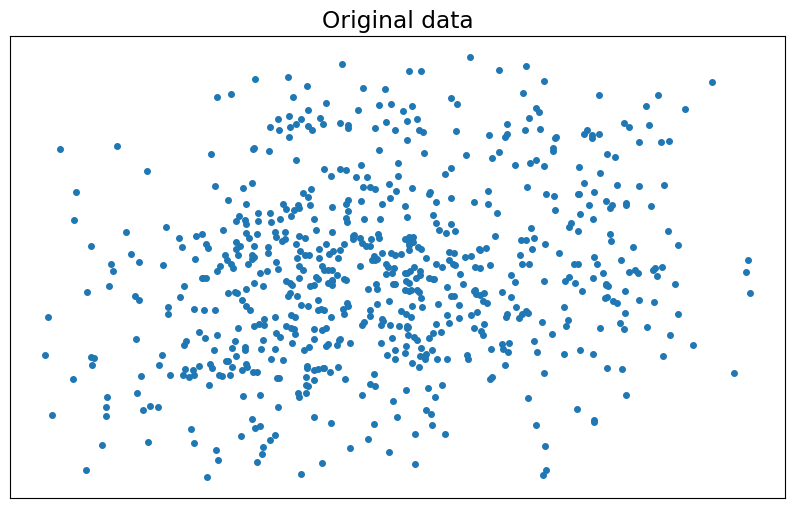

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(M[:, 0], M[:, 1], ".", markersize=8)
plt.xticks([])
plt.yticks([])
xlim, ylim = plt.xlim(), plt.ylim()
plt.title("Original data")
plt.show()

## Cluster with $k = 20$ and $k = 4$

Two lines do the actual work; everything else is plotting. Stars are the centroids, points are colored by their assigned cluster.

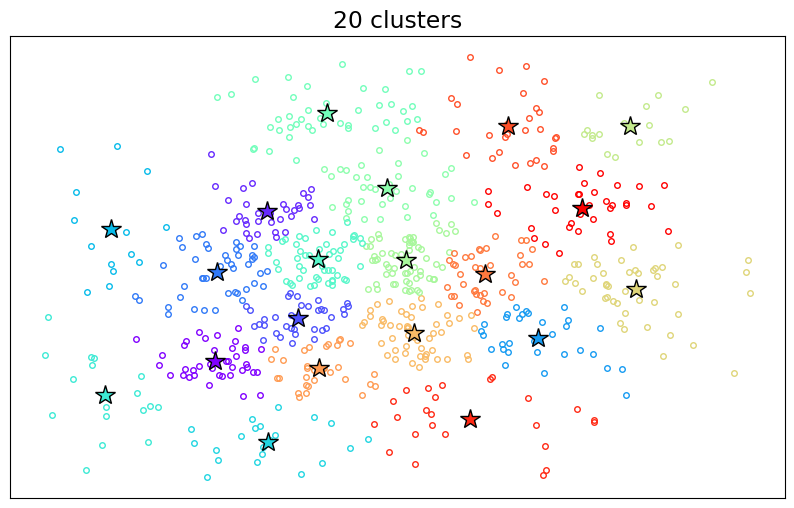

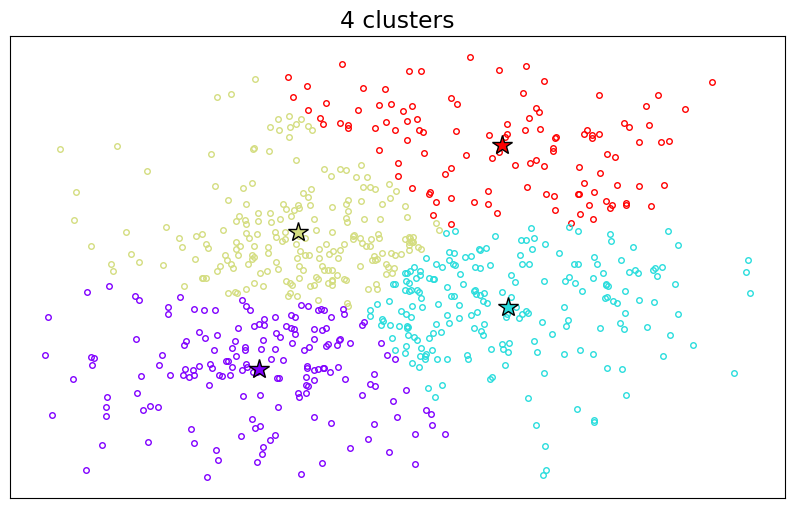

In [4]:
for n_clusters in [20, 4]:
    centroids, _ = kmeans(M, n_clusters, iter=20)
    idx, _ = vq(M, centroids)

    colors = cm.rainbow(np.linspace(0, 1, n_clusters))

    plt.figure(figsize=(10, 6))
    plt.title(f"{n_clusters} clusters")

    for i, point in enumerate(M):
        plt.plot(
            point[0],
            point[1],
            ".",
            color=colors[idx[i]],
            markersize=8,
            markerfacecolor="none",
        )
    for i, c in enumerate(centroids):
        plt.plot(
            c[0], c[1], "*", color=colors[i], markersize=15, markeredgecolor="black"
        )

    plt.xticks([])
    plt.yticks([])
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.show()

## Wrap-up

Both partitions are valid k-means outputs, and both *look* like clustering — neat boundaries, evenly distributed centroids. But the underlying data is essentially a single blob.

The lesson is the same one we keep coming back to: k-means will **always** give you $k$ clusters. Whether those clusters are meaningful is your call, not the algorithm's. Validate with domain knowledge, an elbow plot, silhouette scores, or by checking that the clusters are stable across restarts and seeds.